<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Introduction to Deep Learning and Regression Workshop

In this session we are going to see

- A quick introductory session on what **Deep Learning is** and how it has been **applied** in Astronomy.

- what **regression is** and some **metrics**

- how we **set up a model** to make predictions.

## Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

import time
import keras
from keras.layers import Activation, Dropout, Flatten, Dense, Input, BatchNormalization,Conv3D, MaxPooling3D, Dense, Add, Activation
from keras.regularizers import l2
from keras.models import Model, Sequential
from keras.optimizers import Adam, SGD, Adagrad, RMSprop

from astropy.io import fits
from astropy.table import Table

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from IPython.display import clear_output

Repository:
https://github.com/AstroStat-Academy/astrostat-school-7.git

Branch:
main

Working in:
/content/astrostat-school-7/DL_Intro_n_Regression

Content:
	 ['Intro_n_Regression.ipynb', 'data', 'images']
Imported matplotlib.
Imported seaborn.
Plotting style set.


# Why Deep Learning is cool


    It is not, we are geeks, and that's the truth.

However ... we do live in the era of "Big Data":



<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Survey_Size_Evolution.png?raw=1" width=550 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=550>
        <center>
            <br>
            Figure 1.  Current and projected survey size evolution.
        </center>
    </td>
</tr></table>


We cannot expect to humanly inspect these data and derive the intuition for the _rules_ which categorize them.

$\rightarrow$ We have to leverage on:

- the **large number** of examples

- algorithms that can abstract **arbitrarily complex** rules


## A bit of history


The history of NNs is troubled.  Arguably, NNs have been originally inspired by _biological_ neurons.

**1943** $\rightarrow$ **Warren McCulloch** (neurophysiologist) and **Walter Pitts** (mathematician)<br>
&emsp; _Simplified computational model of how biological neurons might work together in animal brains_

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Cortex.png?raw=1" width=800 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=800>
        <center>
            <br>
            Figure 3.  Neuron layers in the human cortex.
            <br>
            (Adapted from Figure 10-2 of <a href="https://github.com/ageron/handson-ml2">Gerone A. 2017</a>)
        </center>
    </td>
</tr></table>


**mid'40s$-$'60s** $\hspace{0.6cm}$ $\rightarrow$ Follows some interest and development of early models (e.g. **Perceptron**)

**'70s$-$mid'80s**  $\hspace{0.6cm}$ $\rightarrow$ NNs cannot scale efficiently, they get **disregarded**

**mid'80s$-$mid'90s** $\rightarrow$ The invention of **backpropagation** allows to train complex NNs, but ...

**mid'90s-2010s** $\hspace{0.5cm}$ $\rightarrow$ Other techniques look simpler, more powerful (e.g. **SVM**)

**2010s$-$present** $\hspace{0.3cm}$ $\rightarrow$ Second reinassance of NNS,  mostly due to:

> - huge quantity of data availability
> - powerful GPU cards (_bad Bitcoin, bad!  Gaming: good boi!_)
> - improvement of training algorithms
> - virtuous circle of funding and progress

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/History_NNS.jpeg?raw=1" width=800 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=800>
        <center>
            <br>
            Figure 4.  The tormented history of NNs.
            <br>
            (From <a href="https://twitter.com/ricard_sole/status/1497306702181548039">here</a>)
        </center>
    </td>
</tr></table>


Today the association to biological NNs is obsolete, and possibly even detrimental (see _sigmoid_ activation function).


## Deep Learning in Astronomy


Astronomy got a **late start** to the DL race ( _prejudice against the "black box"_ vs. _old school statistics?_ ).<br>
However ...

Astronomy is the perfect DL lab because it offers:
- tough problems to solve
- large data

In fact, Deep Learning publications are **exploding** in Astronomy!

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Deep_Learning_astro_papers.png?raw=1" width=550 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=550>
        <center>
            <br>
            Figure 5. Number of refereed astronomy papers containing the text "Deep Learning" in their abstracts (~66.3K).<br>
            (From <a href="https://ui.adsabs.harvard.edu/">NASA ADS</a>)
        </center>
    </td>
</tr></table>


<u>**Some notable examples**</u>

**Galaxy Classification**
    
- [Dieleman et al. (2015), MNRAS, 450, 1441](https://ui.adsabs.harvard.edu/abs/2015MNRAS.450.1441D/abstract) $-$ calculate probabilities for the 37 Galaxy Zoo possible answers

    - **training**: classification of 61,578 JPEG images from SDSS with GZ labels
    - **architecture**: standard CNN

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/P_Dieleman_Fig11_Galaxy_Zoo_flowchart.png?raw=1" width=1000 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=1000>
        <center>
            <br>
            Figure 6. <i>Left</i> $-$ Galaxy Zoo classification tree (From <a href="https://ui.adsabs.harvard.edu/abs/2013yCat..74352835W/abstract">Willet et al. 2013</a>).
            <i>Right</i> $-$ Activation of the CNN layers (From <a href="https://ui.adsabs.harvard.edu/abs/2015MNRAS.450.1441D/abstract">Dieleman et al. 2015</a>).
        </center>
    </td>
</tr></table>


- [Ackerman et al. 2017, MNRAS, 479, 415](https://ui.adsabs.harvard.edu/abs/2018MNRAS.479..415A/abstract) $-$ identify mergers

    - **training**: classification of ~4000 JPEG images from SDSS with GZ labels
    - **architecture**: CNN with transfer learning


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/P_Ackerman_Fig8.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=600>
        <center>
            <br>
            Figure 7. Some galaxy pairs confidently identified as mergers.<br>
            (From <a href="https://ui.adsabs.harvard.edu/abs/2018MNRAS.479..415A/abstract">Ackerman et al. 2017</a>)
        </center>
    </td>
</tr></table>


**Serendipitous Detection**  
    
- [Lanusse et al. 2018, MNRAS, 473, 3895](https://ui.adsabs.harvard.edu/abs/2018MNRAS.473.3895L/abstract) $-$ spot gravitational lenses

    - **training**: 20,000 LSST-like observations
    - **architecture**: CNN + ResNet
    

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/P_DeepLens_Fig8.png?raw=1" width=480 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=480>
        <center>
            <br>
            Figure 8. Some images correctly identified as hosting lenses.<br>
            (From <a href="https://ui.adsabs.harvard.edu/abs/2018MNRAS.473.3895L/abstract">Lanusse et al. 2018</a>)
        </center>
    </td>
</tr></table>

**Image Reconstruction**
       
- [Schawinski et al. 2017, MNRAS, 467, 110](https://ui.adsabs.harvard.edu/abs/2017MNRAS.467L.110S/abstract) $-$ image denoising

    - **training**: 4550 nearby SDSS galaxies
    - **architecture**: GAN

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/P_Schawinski_Fig2.png?raw=1" width=800 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=800>
        <center>
            <br>
            Figure 9. Degraded image details reconstructed by a GAN.<br>
            (From <a href="https://ui.adsabs.harvard.edu/abs/2017MNRAS.467L.110S/abstract">Schawinski et al. 2017</a>)
        </center>
    </td>
</tr></table>


**Cosmological Simulations**
    
- [Rodríguez et al. 2018, ComAC, 5, 4](https://ui.adsabs.harvard.edu/abs/2018ComAC...5....4R/abstract) $-$ create computationally _cheap_ cosmological simulations

    - **training**: 10 independent L-PICOLA simulation boxes
    - **architecture**: GAN
    
<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/P_Rodriguez_Fig1.png?raw=1" width=800 style="display:block; margin-left:auto; margin-right:auto;">    

<table><tr>
    <td width=800>
        <center>
            <br>
            Figure 10. Comparison between the results of a N-body simulation (<i>left</i>) and from a GAN (<i>right</i>).<br>
            (Adapted from <a herf="https://ui.adsabs.harvard.edu/abs/2018ComAC...5....4R/abstract">Rodríguez et al. 2018</a>)
        </center>
    </td>
</tr></table>


**Source Density Predicition**

- [Xu et al. 2023, ApJ, 950, 2](https://ui.adsabs.harvard.edu/abs/2023arXiv230401670X/abstract) $-$ get a census of Giant Molecular Clouds (GMCs) from their $N_H$ column-density images
    
    - **training**: 7179 high-res MHD simulations of clouds
    - **architecture**: Diffusion Models

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/P_Xu_Fig2.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=600>
        <center>
            <br>
            Figure 11. The true GMC number density (<i>bottom-left</i>) is iteratively reconstructed, conditioned on the line-of-sight $N_H$ column density (<i>top-left</i>) .<br>
            (From <a href="https://ui.adsabs.harvard.edu/abs/2023arXiv230401670X/abstract">Xu et al. 2023, ApJ, 950, 2</a>)
        </center>
    </td>
</tr></table>


**Inference of Cosmological Parameters**

- [Jeffrey et al. 2025, MNRAS, 536, 2](https://ui.adsabs.harvard.edu/abs/2025MNRAS.536.1303J/abstract) $-$ constrain
$𝑤$CDM cosmological parameters using SBI on Dark Energy Survey weak-lensing maps
    
    - **training**: 791 full-sky $N$-body simulations
    - **architecture**: Simulation Based Inference + NN compression

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/P_Jeffrey_Fig14.png?raw=1" width=480 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=480>
        <center>
            <br>
            Figure 12. Corner plot of the posteriors for <i>&Omega;<sub>m</sub></i>, <i>S<sub>8</sub></i>, and <i>w</i>.<br>
            (From <a href="https://ui.adsabs.harvard.edu/abs/2025MNRAS.536.1303J/abstract">Jeffrey et al. 2025</a>)
        </center>
    </td>
</tr></table>


# Neural Networks (NN) Components


## Generic Architecture and Neurons
<a id='Generic_Architecture_and_Neurons'></a>


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Generic_Architecture.png?raw=1" width=640 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=640>
        <center>
            <br>
            Figure 13.  A simple, generic <i>feedforward</i> deep neural architecture.  Neurons of a layer might be connected to al the neurons of the neighboring layers, like in this example (<i>fully-connected</i> layers), or not.<br>
            (Adapted from <a href="https://ui.adsabs.harvard.edu">here</a>)
        </center>
    </td>
</tr></table>


<u>**Nomenclature**</u>
    
**Neuron**: A simple element in a network, carrying 1 value.
    
**Layers**: A collection of neurons activated simultaneously.<br>
    
    Layers are represented differently depending on the architecture.
    E.g., fully-connected layers (as in the Figure above), appear as vertical stripes of neurons.
  
- **input layer**: the data
- **hidden layers**: the internal layers ("_hidden_" from the point of view of the NN user)
- **output layer**: the variable(s) of interest (e.g., class(es) or $y$)
    
    
    E.g., if we provide an image as input, each pixel is 1 neuron of the input layer.


Contemporary NNs contain hundreds to thousands of layers, with millions to billions of neurons.


## Weights and Biases


The core of the functioning of any NN is how the **information flows** through a neuron.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/neuron_flow.gif?raw=1" width=800 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=800>
        <center>
            <br>
            Figure 14.  How the information is propagated through a neuron.<br>
            (Image by P. Bonfini, Astrostatistics in Crete, made with <a href="https://github.com/ManimCommunity/manim">Manim</a>, free reproduction)
        </center>
    </td>
</tr></table>

1. **The first stage is <u>linear</u>:**<br>
    A neuron takes all the inputs (values) x$_i$ directed into it, multiplies each of them by a different _weight_ ($w_i$), and takes the sum.<br>
    Then, it adds a _bias_ ($b$).
<br>

2. **The second stage is (usually) <u>non-linear</u>:**<br>
    The summation is passed to an **activation function**.<br>
    The activation function acts as a filter, basically deciding when and how the information shall flow.

The ouput of a single **neuron** is therefore:

   $$ \hat{y} = f\left( \sum \mathbf{w} \cdot \mathbf{x} + b \right) $$

<br>

<u>**IMPORTANT**</u>

The _weights_ and _biases_ are <u>the</u> elements that are fit during the training of the model!

Fitting a model == optimizing **all** the _weights_ and _biases_ within the NN, in order to **approximate** the desired output $y$ given a corresponding example $x$.

## Activation Functions


Activation functions are what make NNs so **efficient** as universal tools.

They introduce <u>non-linearities</u> $\rightarrow$ a NN can create an arbitrarily complex model.

They can be basically **any** _filter_-like function, but they better posses [some of] these features:

- **computationally inexpensive** $\leftarrow$ hence simple, since they get executed at each neuron

- **zero-centered** $\leftarrow$ not to shift values towards a preferential direction

- **differentiable** $\leftarrow$ because NNs work with [Backpropagation](#Error-Function,-Gradient-Descent-and-Backpropagation)

- **avoid vanishing when chained** $\leftarrow$ more correctly, we need to avoid vanishing gradients<br>
  &emsp; (see [Gradient Descent and Loss](#Error-Function,-Gradient-Descent-and-Backpropagation), and [Glorot & Benjo 2010](https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf))

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Activation_Functions.png?raw=1" width=500 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=500>
        <center>
            <br>
            Figure 15.  A collection of commonly used activation functions<br>
            (Adapted from <a href="https://wandb.ai/lavanyashukla/vega-plots/reports/Natural-Language-Processing--Vmlldzo2Nzk2Ng">here</a>)
        </center>
    </td>
</tr></table>


## NN Architecture Variants


NN come in **countless architectures**, and even trying to classify them is a tough task ...

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/NN_Zoo.png?raw=1" width=640 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=640>
        <center>
            <br>
            Figure 16.  A reasonably complete scheme of basic NN architectures.<br>
            (Image credit: <a href="https://www.asimovinstitute.org/author/fjodorvanveen/">Fjodor van Venn</a>)
        </center>
    </td>
</tr></table>


# Training NNs


As mentioned above:

    training a NN = optimize its weights and biases
    
in order to produce the desired output (class or values) given a corresponding input.

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

The details of the training method depends on the DL learning problem:

- **supervised:** we have labelled examples
- **unsupervised:** no labeles are available
- **reinforced:** the examples are associated to a "reward"

In this notebook, we will focus on the **supervised** case to illustrate the NN mechanics:<br>
$\rightarrow$ Let's assume we have some predicting variables $X$, and labels $y$.

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

How can we _tell_ the network in which way it shall modify weights (and biases)?<br>
Let's break down the NN rationale:

> 1. We initialize the weights to some arbitrary value
> 2. We take a sub-sample (**batch**) of the data $X$, $X_{batch}$
> 3. We propagate $X_{batch}$ through the network, obtaining a predicted $\hat{y}_{batch}$
> 4. We assess the **error** between $\hat{y}_{batch}$ and the true $y_{batch}$
> 5. We need to **backpropagate** back the information about the difference
> 6. We need to **update** the weights in the right direction
> 7. Repeat from step 2 untill all data are used
> 8. (Repeat from 2 for multiple **epochs**)

The critical steps are #4, #5 and #6.


## Error Function, Gradient Descent and Backpropagation


Let's consider an **errorr** (a.k.a. **loss**, or **cost**) function:

$$ E (\hat{y}, y) $$

which assesses the intensity of the error.  For _example_, we might adopt: $E (\hat{y}, y) = {1\over2}(\hat{y} - y)^2 $.

To be precise, $\hat{y}$ is itself a function of the input $\boldsymbol{x}$, and of the NN parameters $\theta$ (all the $w$ and $b$ of each node):

$$ \hat{y} = f(\boldsymbol{x}, \theta) $$

therefore:

$$ E = E (\boldsymbol{x}, y, \theta) $$

**Our objective:** Minimize the error by finding the optimal set $\hat{\theta}$, i.e.:
$$ \hat{\theta} = \min_{\theta} E(\boldsymbol{x}, y, \theta) $$

<u>**A useful consideration**</u>

The **gradient** of $E$ with respect to $\theta$, i.e. $\nabla_{\theta} E (\boldsymbol{x}, y, \theta)$, is a vector _roughly_ pointing towards the minimum of $E$:


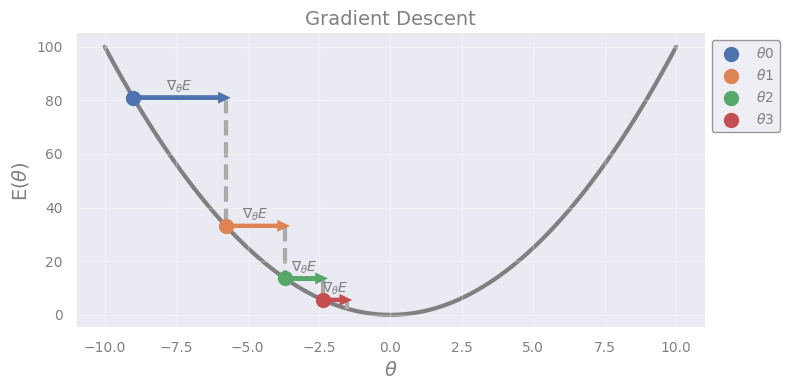

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def E(theta): return theta**2
def dE_dtheta(theta): return 2*theta

thetas = np.linspace(-10, 10, 400)
theta = -9
'''First guess for the parameter''';
eta = 0.18
'''Learning rate: try to change this to small/large values (e.g., 0.08, or 1)''';

plt.figure(figsize=(8, 4))
plt.title('Gradient Descent')

plt.plot(thetas, E(thetas), c='grey', lw=3, zorder=-1)

for i, color in enumerate(['C0', 'C1', 'C2', 'C3']):
    plt.scatter(theta, E(theta), s=100, c=color, label=r'$\theta$'+str(i))
    #
    theta_prime = theta - eta*dE_dtheta(theta)
    plt.arrow(theta, E(theta), theta_prime - theta, 0, lw=3, head_width=2, head_length=0.2, fc=color, ec=color, length_includes_head=True)
    plt.plot([theta_prime, theta_prime], [E(theta), E(theta_prime)], '--', lw=3, c='darkgrey', zorder=-1)
    plt.text((theta + theta_prime) / 2, E(theta) + 1, r'$\nabla_{\theta} E$', ha='center', va='bottom')
    #
    theta = theta_prime

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel(r'E($\theta$)', fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.show()

We can therefore **update** the weights by adding a vector proportional to $\nabla_{\theta} E$:

$$ \theta^\prime = \theta - \eta \cdot \nabla_{\theta} E ~~~~~(1)$$

where the proportionality constant $\eta$ is called **learning rate** (**LR**) because it regulates how fast we shall proceed towards the mininum<br>
(and possibly _overshoot_ it, if $\eta$ is too large).

> _This is the **Gradient Descent** optimization._


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**In-class Exercise**: In the above code block, try to change the value of `eta` to see what happens when the update is _too fast_ or _too slow_

</div>

<u>**Calculating the gradient**</u>

We have $\nabla_{\theta} E~$:

$$ \nabla_{\theta} E =
      \left( \frac{\partial E}{\partial \theta_1},
             \frac{\partial E}{\partial \theta_2},
             . . .,
             \frac{\partial E}{\partial \theta_n}
\right)$$

where the $\theta_i$ are **all** the _weigths_ and _biases_ along the network.

> _.. BUT ... how do I <u>exactly</u> calculate <u>each</u> $\frac{\partial E}{\partial \theta_i}$ ?_

For example, consider the simple network:
- 2 input neurons
- 2 hidden layers, each with 2 neurons
- 2 output neurons

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Backprop_NN.png?raw=1" width=640 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=640>
        <center>
            <br>
            Figure 17.  All the parameters of a 2-hidden-layer NN.<br>
            (From this amazing graphical explanation by <a href="https://towardsdatascience.com/understanding-backpropagation-abcc509ca9d0">Brent Scarff</a>)
        </center>
    </td>
</tr></table>


where, in this **notation**:

> $ z = \sum{\textbf{w}\cdot{}\textbf{x} + b} $<br>
> _is just the neuron value **before** the activation function_
>
> $ a = f(z) $<br>
> _is just the neuron value **after** the activation function_


How do I calculate, e.g.:
$$ \frac{\partial E}{\partial w^{(2)}_{11}} ~~~~~ ?$$


$\rightarrow$ <u>Chain rule of derivatives</u> !


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Backprop_NN.gif?raw=1" width=640 style="display:block; margin-left:auto; margin-right:auto;">

   
<table><tr>
    <td width=640>
        <center>
            <br>
            Figure 18.  Calculating the gradient at a specific position in the NN.<br>
            (Image credit: <a href="https://towardsdatascience.com/understanding-backpropagation-abcc509ca9d0">Brent Scarff</a>)
        </center>
    </td>
</tr></table>


You can imagine **propagating** the chain rule back to the original input: all the steps are either _linear_ or passing through a _differentiable_ activation function!

With that, we now how to update any $w$ and $b$:

> _This is the **Backpropagation** technique._

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

[-] Strongly suggested read: [This blog by Brent Scarff](https://towardsdatascience.com/understanding-backpropagation-abcc509ca9d0).

## Optimization Algorithms

There is a number of different optimizers (such as momentum optimization, AdaGrad, RMSProp, etc).  

But Adam is arguably the **best-performing** optimizer on average:
- quite **robust** with respect to the choice of hyperpars
- usually works with **default** hypepars

$\rightarrow$ Safe choice!
    
**Reading material**
    
At this [page](https://ml-cheatsheet.readthedocs.io/en/latest/optimizers.html) you will find graphical explanations of these and more optimizers as well as their mathematical formulations.


## Learning Curves

In DL, it is common to cycle the training on the same data $N$ times $-$ Each pass is called "**Epoch**".

Training rationale with **N_epochs** epochs, and **N_batches** batches:

    0. set epoch = 0
    1. Train on batch 1, update gradient
       Continue train on batch 2, update gradient
       Continue train on batch 3, update gradient
       .. .
       Continue train on batch N_batches, update gradient
    3. epoch += 1
       (epoch completed)
    4. if epoch <= N_epochs: continue from 1 else stop
    
<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

<u>NOTE:</u>
_This introduces bias towards the training data, but it usually more than compensated by a longer gradient descent._

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

We can display the values of the Loss as a function of  "**time**" $\rightarrow$ **Learning Curves** (**Validation Curves**)

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Learning_Curves.png?raw=1" width=480 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=480>
        <center>
            <br>
            Figure 19.  Learning curves for train and validation set.<br>
            (From <a href="https://www.kaggle.com/code/ryanholbrook/overfitting-and-underfitting">here</a>)
        </center>
    </td>
</tr></table>

We can use them to spot **overfitting** (_train goes much better than validation_) or **underfitting** (_training shows trend to improve_):

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Learning_Curves_types.png?raw=1" width=800 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=800>
        <center>
            <br>
            Figure 20.  Learning curves for train and validation set.<br>
        </center>
    </td>
</tr></table>

<div style="display: flex; justify-content: center;">
    <table style="width: 83%; table-layout: fixed; border-collapse: collapse;">
        <tr>
            <th style="width: 33%; text-align: center; border: 0px solid black;">Underfitting</th>
            <th style="width: 33%; text-align: center; border: 0px solid black;">A good fit</th>
            <th style="width: 33%; text-align: center; border: 0px solid black;">Overfitting</th>
        </tr>
        <tr>
            <td style="width: 33%; text-align: center; border: 0px solid black;">
                The training set shows a downward trend at the right edge: maybe a few more epochs could yield a better performance.
            </td>
            <td style="width: 33%; text-align: center; border: 0px solid black;">
                Training and validation converge <u>and</u> they flatten.<br>
            </td>
            <td style="width: 33%; text-align: center; border: 0px solid black;">
                The validation curve cannot keep up with the training curve.
            </td>
        </tr>
    </table>
</div>


# What you will see in the Workshops

You will explore 3 applications of DL networks:

- **Regression with NN (fully-connected layers)**

- **Simulation Based Inference**

- **Diffusion models**


## Supervised Learning: A simple Deep NN

We will enter the DL coding realm via a simple **Regression** problem.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/Regression_Models.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=600>
        <center>
            <br>
            Figure 21.  The struggle of Regression.<br>
            (Adapted from <a href="https://xkcd.com/2048/">xkcd</a>)<br>
        </center>
    </td>
</tr></table>



<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/DL_Intro_n_Regression/images/NN_Regression.jpg?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=600>
        <center>
            <br>
            Figure 22.  A simple Deep NN can be used as a regressor.<br>
            (From <a href="https://medium.com/@rajatgupta310198/getting-started-with-neural-network-for-regression-and-tensorflow-58ad3bd75223">here</a>)<br>
        </center>
    </td>
</tr></table>


# Libraries

There are several libraries that implement **Deep Learning routines** in Python.

For the Woskshops we will focus on [**Tensorflow**](https://www.tensorflow.org/) ($\rightarrow$ via [**Keras**](https://keras.io/)), and [**PyTorch**](https://pytorch.org/).

- **Tensorflow** (_Google_): does the _heavy lifting_ for us
    - pre-defined **functions** and **layers**
    - automatically computes the **derivatives** (for Backprop!)

- **Keras** (_François Chollet_): is an **API** (_Application Programming Interface_) $-$ it provides **higher-level functionalities** for DL libraries (such as Tensorflow, PyTorch)

- **PyTorch** (_META & Linux foundation_): is a high-level API that builds upon optimised, low-level implementations of deep learning algorithms and architectures (supports GPU, uses tensor as fundamental data type).

Both Keras and PyTorch offer 2 API flavors:

- Sequential
    - PROs: Simpler (_stack of layers_)<br>
    - CONs: Single-input, single-output
    
- Functional
    - PROs: More flexible, multi-input, multi-output<br>
    - CONs: Steep learning curve, need to understand tensor programming

# Regression with Deep Learning

# What is regression ?

    Modeling problems where the output is a continuous numeric value.


# Linear regression and least squares

A linear regression model will try to predict the single value of the dependent variable $y$ given the independent variable $x$, with the most generic form being:

$$y = f (x | β), $$

where $x$ corresponds to the input variable(s) and $β$ is an array of parameters.

The simplest linear model we can think of is a line:

$$y = β_0 + β_1 x $$

where $β_0$ and $β_1$ have the usual meaning of intercept and slope of a line.

Generalizing a bit, for an input vector $x^T = (x_1, x_2, ..., x_N)$,  where $N$ is the total number of observations (or samples), the linear model to predict the real-valued output $y$ is:

$$ f(x) = β_0 + \sum_{i=1}^{N} x_i β_i. $$

To find these parameters we use the Ordinary Least Squares approach, i.e. we try to **minimize** the residual sum of the squares between the observations and the predictions by the model (i.e. the **loss or cost** function):

$$ RSS(β) = \sum_{i=1}^{N} (y_i - f(x_i))^2 =  \sum_{i=1}^{N} (y_i - β_0 - x_i β_i)^2 .$$


# The more general linear regression

Linear regression refers to modeling functions that are linear with respect to the parameters (coefficients) and not with respect to the variables! For example, the function:

$$f (x|β) = \sum_{i=1}^N β_i g_i(x) = β_1 g_1(x) + β_2 g_2(x)~+~...~+~β_N g_N(x) $$

describes a linear problem as long as the sub-functions $g_i(x)$ do not depend on any of the parameters $β_i$. This is not the most generic formulation of the linear regression but we are going to use this form in the following applications.


# On metrics ... or how well can we do

> _Accuracy is a measure for classification not regression_<br>
> _We cannot calculate accuracy for a regression model_
>
>  _by Jason Brownlee [Regression Metrics for Machine Learning](https://machinelearningmastery.com/regression-metrics-for-machine-learning/)_

In regression we are dealing with continuous values. Therefore, it is actually impossible to predict the exact same values. The idea is to get an estimate of how close the predictions are to the expected values.

We are going to refer only a few of the available metrics in [sklearn](https://machinelearningmastery.com/regression-metrics-for-machine-learning/). In the following $y$ refers to the dependent values while $\hat{y}$ to the predicted values.

**--> Mean Squared Error (MSE)**

$$ MSE = \frac{1}{N}\sum_{i=1}^{N} (y_i - \hat{y_i})^2 $$  

It is actually the cost function of the Ordinary Least Squares (check $RSS(β)$ above). The units returned in this case are squared. Best score is 0.

**--> Root Mean Squared Error (RMSE)**

$$ RMSE = \sqrt{ \frac{1}{N}\sum_{i=1}^{N} (y_i - \hat{y_i})^2 } $$  

It returns the square root of MSE so that the units match the units of the target value (so better interpretation).  Best score is 0.

**--> Mean Absolute Error (MAE)**

$$ MAE = {1 \over N}\sum_i^N{|  y_i-\hat{y_i} |}$$  

It is less sensitive to large errors when compared to (R)MSE. The score is in units of the target value.

> Comment: Although arithmetically the best scores for (R)MSE and MAE is 0 this cannot be the case in real-life problems. Instead a baseline model has to be determined and calculate its score. Then, any model that can achieve a score better that the baseline model is accepted as a skillful model.   


**--> R2 (coefficient of determination)**

$$R^2 = 1 - {\sum_{i=1}^N{(y_i-\hat{y_i})^2} \over \sum_{i=1}^N{(y_i - \bar{y})^2}}, $$

where $\bar{y} = \frac{1}{n}\sum_{i=1}^N y_i$.

It represents the proportion of variance (of y) that has been explained by the independent variables in the model. It provides an indication of goodness of fit and therefore a measure of how well unseen samples are likely to be predicted by the model, through the proportion of explained variance. Best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).


# Application 1: Estimate SFR

We will use data derived from the Heraklion Extragalactic Catalogue (HECATE; [Kovlakas et al, 2021](https://ui.adsabs.harvard.edu/abs/2021MNRAS.506.1896K/abstract)) which is an all-sky galaxy catalogue, containing about 200k galaxies (up to z=0.047, D≲200Mpc), and it offers positions, sizes, distances, morphological classifications, star formation rates, stellar masses, metallicities, and nuclear activity classifications.

In particular, we are going to use a dataset from the work of [Kouroumpatzakis et al. 2023](https://ui.adsabs.harvard.edu/abs/2023A%26A...673A..16K/abstract) where they estimate the Star Formation Rates (SFR) and stellar mass using model Spectral Enerny Distributions with a variety of parameters (IR photometry, extinction, and stellar populations).


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise 1:**</font>    

**Objective:** Build a regression model to predict SFR

**Task:** For this follow these steps:
    
- load and investigate the data
    
- select features
    
- pre-process the data
    
- split data (train/validation/test)
    
- build model (architecture with dense layers)
    
- train the model
    
- evaluate its performance
    
- compare with baseline model and check results.

</div>

## Loading and checking data


In [12]:

class PlotLosses(keras.callbacks.Callback):
    # NOTE: the current version can print only the first metric from the list provided
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.losses2 = []
        self.val_losses2 = []

        self.fig = plt.figure()

        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.losses2.append(logs.get( test_metrics[0] ) )
        self.val_losses2.append(logs.get( f'val_{test_metrics[0]}' ))
#         print(test_metrics[0] , logs.get( test_metrics[0] ), logs.get( f'val_{test_metrics[0]}' ))
#         print(self.losses2)

        self.i += 1

        clear_output(wait=True)
        plt.subplot(1,2,1)
        plt.plot(self.x, self.losses2, label="Train",linestyle='-')
        plt.plot(self.x, self.val_losses2, label="Validate",linestyle='--')
#        plt.ylim(0,1)
        plt.legend()
        plt.xlabel('Epoch')
        plt.ylabel(test_metrics[0])

        plt.subplot(1,2,2)
        plt.plot(self.x, self.losses, label="Train",linestyle='-')
        plt.plot(self.x, self.val_losses, label="Validate",linestyle='--')

        plt.legend()
        plt.xlabel('Epoch')
        plt.ylabel('Loss')

        plt.tight_layout()

        plt.show();

plot_losses = PlotLosses()


def sub_ploots(plots_cols, plots_array):
        """ Automatic adjustment of subplots
        Given the
        plots_cols     : plots per row (set manually)
        plots_array    : array from which the number of
                         individual subplots is derived

        the output is given as
        plots_cols     : plots per row
        plots_rows     : number of necessary rows to create
        """
        plots_unique = len((list(set(plots_array))))
        plots_rows = int(np.ceil(plots_unique/plots_cols))

        return plots_rows, plots_cols

In [13]:
# following this tutorial :https://learn.astropy.org/tutorials/FITS-tables.html

data_fits = fits.open('data/CIGALE_SFR.fits', memmap=True)

# printing some information
data_fits.info()
print('-----')
print(data_fits[1].columns)

Filename: data/CIGALE_SFR.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (911,)   uint8   
  1  /home/grigoris/Projects/AstroStatisticsCrete-2025/2025_summer_sch...    1 BinTableHDU     34   123908R x 11C   [D, D, D, D, D, D, D, D, D, D, D]   
-----
ColDefs(
    name = 'sfr'; format = 'D'
    name = 'mstar'; format = 'D'
    name = 'IRX'; format = 'D'
    name = 'EBVs'; format = 'D'
    name = 'LYoungOld'; format = 'D'
    name = 'NIR200'; format = 'D'
    name = 'MIRI2100'; format = 'D'
    name = 'W1'; format = 'D'
    name = 'W2'; format = 'D'
    name = 'W3'; format = 'D'
    name = 'W4'; format = 'D'
)


**Note on columns:**

```
       'sfr' : Star Formation Rate
     'mstar' : Stellar Mass
       'IRX' : IR excess ratio
      'EBVs' : extinction
 'LYoungOld' : ratio of luminosity of young to old populations
   'NIR200' : JWST NIR-F200W
 'MIRI2100' : JWST MIRI-F2100W
       'W1' : WISE 3.4 μm
       'W2' : WISE 4.6 μm
       'W3' : WISE 12 μm
       'W4' : WISE 22 μm
```

Printing the data table.


In [14]:
data_tab = Table(data_fits[1].data)
data_tab

sfr,mstar,IRX,EBVs,LYoungOld,NIR200,MIRI2100,W1,W2,W3,W4
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-1.7775958737441702,8.88439002050874,1.0597066442746876,0.075,-1.161582684412036,20.57568201275021,20.915356290620906,20.283857754272237,20.07785242628705,20.749168886908052,20.977838069609653
-5.598150103513504,7.163475768985803,0.6090525930420546,0.075,-3.095438541121911,18.699843670803883,18.71021154983641,18.380386821972536,18.169375587980156,18.556209527608885,18.77235612162204
0.46026919969367264,9.555252512015649,1.902715602377176,0.12,-0.007993003792127648,21.24489484510881,22.644248708956212,21.234736799549726,21.25041706188928,22.46532446497027,22.707373655941282
2.4145309631249785,10.32453156040969,1.399250989811699,0.06,0.59695867241776,23.240506755171285,24.305480238065996,23.0619764044172,23.01596122061309,24.127836105292985,24.356805745021273
-3.2602550268517,8.694262138626932,1.5825219675250681,0.24,-2.6966069354956685,20.478382255352365,21.17948475308555,20.222128818087356,20.063940269851575,21.003583359324065,21.242689708753176
-3.8229180838972106,8.827694847737332,0.794228535480207,0.06,-2.6499464090799667,20.175890232692996,20.04636052688319,19.85353655051953,19.621751170933265,19.900476164368083,20.10778046646713
0.8506413438533907,9.465027116409965,1.6451465950450486,0.12,0.42176281956076034,21.583159957555335,22.862224270730703,21.464771982664036,21.462010041607755,22.70072019878477,22.917040470013063
0.3212462542445377,8.46334364974829,1.9219557531126592,0.195,1.943541695128508,20.53529154234542,22.23356572282868,20.641662695014567,20.73772356328627,22.06708673225438,22.29388843053493
0.34317898627799476,8.287711611276643,1.9519193931772922,0.18,0.38600979614344816,20.545438547880376,22.456827133479848,20.8170107257701,20.952689859912386,22.277083741941293,22.519956006914548


## Selecting features

In this part we can select which features we want to keep and use to train our model. Feel free to choose any number of feature - keep in mind though **NOT** to select `sfr` and `mstar` as these are needed for the output (i.e. are the values we want to predict).


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** select the features to work with

</div>

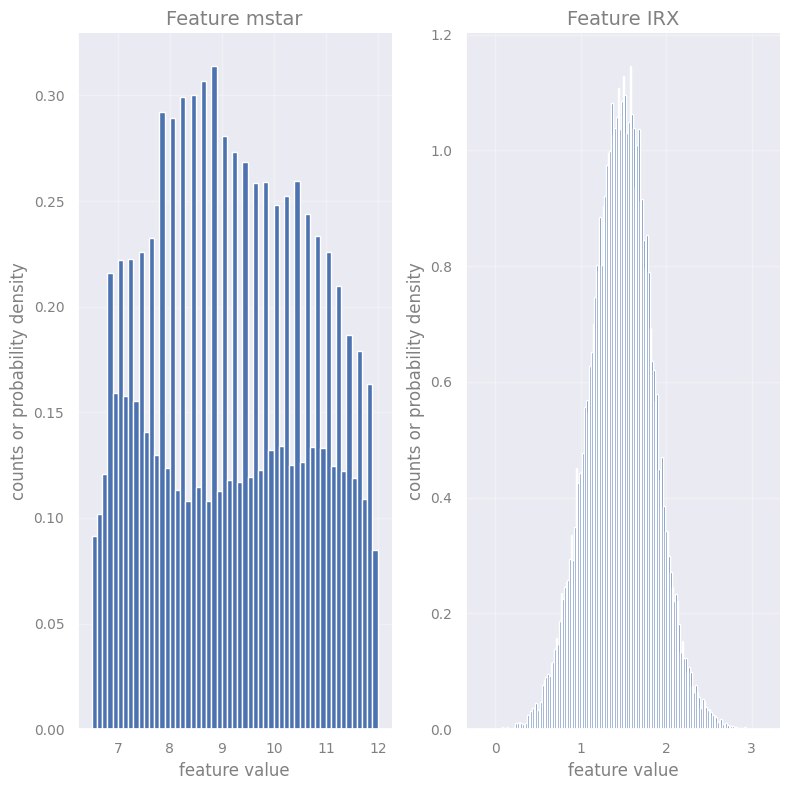

In [15]:
sel_features = ['mstar', 'IRX']

fig = plt.figure(figsize=(8,8))

rws, cls = sub_ploots(2, sel_features)  # for subplots
for f in range(len(sel_features)):
    f_name = sel_features[f]
    ax = fig.add_subplot(rws, cls, f+1)
    ax.set_title(f'Feature {f_name}')
    ax.hist(data_tab[f_name], bins='auto', align='mid', density=True)
    ax.set_xlabel('feature value')
    ax.set_ylabel('counts or probability density')

plt.tight_layout()
plt.show()

In [16]:
len(data_tab)

123908

and the data table with the _selected features_ looks like ...


In [17]:
data_tab[sel_features]

mstar,IRX
float64,float64
8.88439002050874,1.0597066442746876
7.163475768985803,0.6090525930420546
9.555252512015649,1.902715602377176
10.32453156040969,1.399250989811699
8.694262138626932,1.5825219675250681
8.827694847737332,0.794228535480207
9.465027116409965,1.6451465950450486
8.46334364974829,1.9219557531126592
8.287711611276643,1.9519193931772922


We convert table objects into numpy arrays:


In [18]:
values = data_tab[sel_features].as_array()
values = values.view((float, len(values.dtype.names)))
target = np.array(data_tab['sfr']).reshape(-1,1)

print('The values for selected features:')
print(values)
print()
print('The target quantity:')
print(target)

The values for selected features:
[[ 8.88439002  1.05970664]
 [ 7.16347577  0.60905259]
 [ 9.55525251  1.9027156 ]
 ...
 [ 8.2272979   1.06892832]
 [11.23385302  1.28714579]
 [ 8.25822978  1.78640711]]

The target quantity:
[[-1.77759587]
 [-5.5981501 ]
 [ 0.4602692 ]
 ...
 [-2.56037601]
 [-1.62659848]
 [-0.28624628]]


## Split the sample and ... ?


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Tasks:**

- split the sample into train/validation/test

- what should you do before training the model?

</div>

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# keep aside the test set first (coming from the future!)
X_train_full, X_test_un, y_train_full, y_test = train_test_split(values, target,
                        test_size= 0.3 ) #, random_state=42)

# split the remaining sample intro train and validation
X_train_un, X_valid_un, y_train, y_valid = train_test_split( X_train_full, y_train_full,
                        test_size= 0.3 ) #, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_un)
X_valid = scaler.transform(X_valid_un)
X_test = scaler.transform(X_test_un)

print(f'> From {len(target)} sources:')
print(f'   {len(X_train)} (train)')
print(f'   {len(X_valid)} (validation)')
print(f'   {len(X_test)} (test)')
print('\n> Statistics per feature:')
print(f'Mean: {scaler.mean_}')
print(f'Variance: {scaler.var_}')
print()
print(f' Target shape: {y_train.shape}') # print the shape of the output values


> From 123908 sources:
   60714 (train)
   26021 (validation)
   37173 (test)

> Statistics per feature:
Mean: [9.20035764 1.46891974]
Variance: [2.23620804 0.14237581]

 Target shape: (60714, 1)


## Time to build our model!


In [20]:
# if you want you can add more output metrics!
# but keep in mind that the plot_losses will use the first one.

test_metrics = [ 'mean_squared_error', 'mean_absolute_error' ]

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Tasks:**

- build a DL network with a number of dense layers - you can add as many layers as you want (probably you may need to return to correct this).  

- how many nodes the last layer should have?

</div>

In [25]:
model = Sequential()

model.add( Dense( 2 , input_shape=X_train_full.shape[1:], activation='relu') )

# model.add( Dense( 2, activation='relu') )
# ...

model.add( Dense(1) )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
optzr = Adam(learning_rate=1e-4)
model.compile(loss='mean_squared_error', optimizer=optzr,
              metrics = test_metrics)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

## Finally ... train the model!


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** Fill the missing code to train the model

</div>

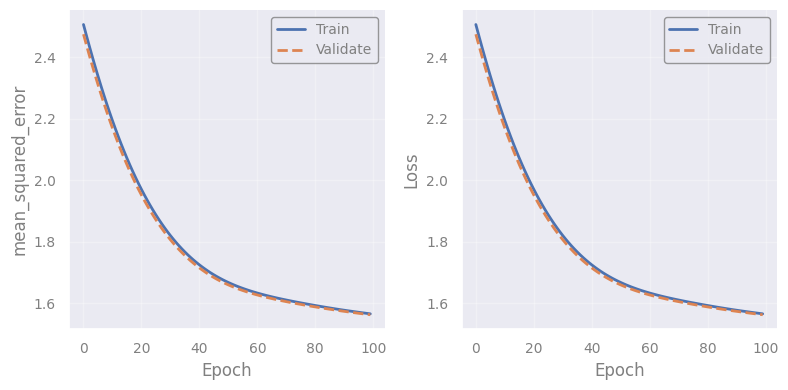

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5658 - mean_absolute_error: 1.0048 - mean_squared_error: 1.5658 - val_loss: 1.5628 - val_mean_absolute_error: 1.0018 - val_mean_squared_error: 1.5628


'00:01:33'

In [29]:
start_time = time.time()

history=model.fit( X_train , y_train ,
                    batch_size= 512 ,
                    epochs= 100 ,
                    validation_data=[ X_valid , y_valid ],
                    callbacks=[plot_losses],shuffle=True)

# to print history contents
# history.history
elapsed_time = time.time() - start_time
time.strftime("%H:%M:%S", time.gmtime(elapsed_time))

## ... and the moment of truth - evaluation


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** evaluate the model (take care on which dataset!)

</div>

In [30]:
evaluation = model.evaluate( X_test , y_test )
print(f"Loss value: {evaluation[0]:.2f}")
for m in range(len(test_metrics)):
    print(f"{test_metrics[m]}: {evaluation[m+1]:0.2f}")


1162/1162 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.5729 - mean_absolute_error: 1.0051 - mean_squared_error: 1.5729
Loss value: 1.57
mean_squared_error: 1.57
mean_absolute_error: 1.01


## Comparing with a baseline model...


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** fill in the code to train and evaluate the baseline model.

</div>

In [31]:
lr_model = LinearRegression()
lr_model.fit( X_train , y_train )
y_hat_lr = lr_model.predict( X_test)

mse = mean_squared_error( y_test , y_hat_lr )
mae = mean_absolute_error( y_test , y_hat_lr )
r2 = r2_score( y_test , y_hat_lr)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 : {r2:.2f}" )

MSE: 1.64
MAE: 1.02
R2 : 0.57


## Checking the predicitons


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** fill in the code to check the results.

</div>

1162/1162 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


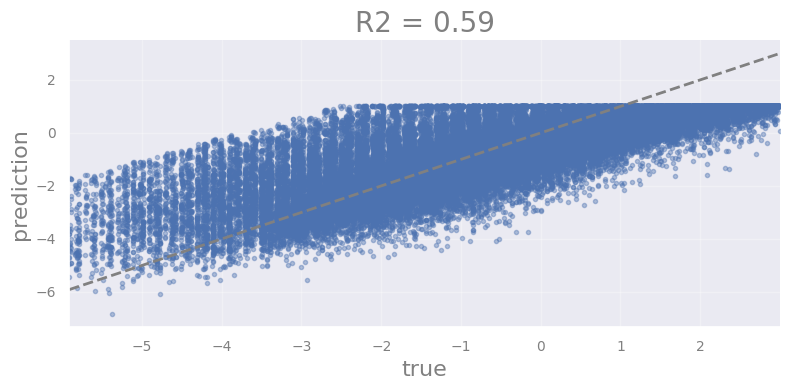

In [32]:
y_hat = model.predict( X_test )

r2 = r2_score( y_test , y_hat )

min_ax, max_ax = np.min(y_test), np.max(y_test)

plt.plot(y_test, y_hat, '.', alpha=0.4)
plt.title( f'R2 = {r2:0.2f}', fontsize=20)
plt.xlabel('true', fontsize=16)
plt.ylabel('prediction', fontsize=16)
plt.xlim([min_ax, max_ax])

# 1-to-1 line:
xx = np.linspace(min_ax, max_ax, 100)
plt.plot(xx, xx, c="grey", linestyle='--')

plt.show()

# Application 2: Estimate SFR and stellar mass


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise 2:**</font>    

**Objective:** Build a regression model to predict both SFR ('sfr') and stellar mass ('mstar').

**Task:** Follow the same steps with the previous exercise. You need to adjust the model to train and predict both values.

</div>


In this case we want to use all/part of the available features to estimate both the SFR (`sfr`) **and** the stellar mass (`mstar`).

Reminder of the available features:

In [ ]:
print(data_fits[1].columns)

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** Select the features to work with. The features we want to predict now are two, the SFR and the stellar mass.

</div>

In [ ]:
sel_features = [ 'sfr', 'mstar' ]
pre_features = [ ... ]

values = data_tab[sel_features].as_array()
values = values.view((float, len(values.dtype.names)))

target = data_tab[pre_features].as_array()
target = target.view((float, len(target.dtype.names)))


print('The values for selected features:')
print(values)
print()
print('The target quantity:')
print(target)


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Tasks:**

- split the sample into train/validation/test

- what should you do before training the model?

</div>

In [ ]:
# keep aside the test set first (coming from the future!)
X_train_full, X_test_un, y_train_full, y_test = train_test_split(... ,...,
                        test_size= ...) #, random_state=42)

# split the remaining sample intro train and validation
X_train_un, X_valid_un, y_train, y_valid = train_test_split( ... , ...,
                        test_size= ...) #, random_state=42)

scaler = ...
X_train = scaler.fit_transform( ... )
X_valid = scaler.transform( ... )
X_test = scaler.transform( ... )

print(f'> From {len(target)} sources:')
print(f'   {len(X_train)} (train)')
print(f'   {len(X_valid)} (validation)')
print(f'   {len(X_test)} (test)')
print('\n> Statistics per feature:')
print(f'Mean: {scaler.mean_}')
print(f'Variance: {scaler.var_}')
print()
print(f' Target shape: {y_train.shape}') # print the shape of the output values


We define the metrics again here:


In [ ]:
# if you want to add more output metrics
test_metrics = ['mean_squared_error', 'mean_absolute_error', ]

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** Building our new model. Watch out the number of nodes at the very last step!

</div>

In [ ]:
model = Sequential()

model.add( Dense(,,,, input_shape=X_train.shape[1:], activation='relu') )

model.add( Dense(..., activation='relu') )
...

model.add( Dense(...) )

In [ ]:
optzr =  Adam(learning_rate=1e-4)
model.compile(loss= 'mean_squared_error',  # custom_loss,
              optimizer=optzr,
              metrics = test_metrics)

model.summary()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** Train the model

</div>

In [ ]:
start_time = time.time()

history=model.fit( ... , ... ,
                    batch_size= ...,
                    epochs= ...,
                    validation_data=[ ... , ...],
                    callbacks=[plot_losses],shuffle=True)

# to print history contents
# history.history
elapsed_time = time.time() - start_time
time.strftime("%H:%M:%S", time.gmtime(elapsed_time))

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** Compare with baseline model.

</div>

In [ ]:
lr_model = LinearRegression()
lr_model.fit( ... , ...)
y_hat_lr = lr_model.predict( ... )

mse_lr = mean_squared_error(  ... , ...)
mae_lr = mean_absolute_error( ... , ...)
r2_lr = r2_score(y_test, y_hat_lr, multioutput='raw_values')
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"R2 (sfr): {r2_lr[0]:0.2f} ")
print(f"R2 (mstar): {r2_lr[1]:0.2f} ")


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** check the results.

</div>

In [ ]:
evaluation = model.evaluate( ... , ...)
print(f"Loss value: {evaluation[0]:.2f}")
for m in range(len(test_metrics)):
    print(f"{test_metrics[m]}: {evaluation[m+1]:0.2f}")

print('------')

y_pred = model.predict( ... )

fig, axes = plt.subplots(1,2, figsize=(12,6))
axes = axes.flatten()

for i, ax in enumerate(axes):

    r2 = r2_score( y_test[:,i] , y_pred[:,i])
    print(i, r2)

    min_ax, max_ax = np.min(y_test[:,i]), np.max(y_test[:,i])

    ax.plot(y_test[:,i], y_pred[:,i], '.', alpha=0.4)
    ax.set_title( f'R2 = {r2:0.2f} for {pre_features[i]}', fontsize=20)
    ax.set_xlabel('true', fontsize=16)
    ax.set_ylabel('prediction', fontsize=16)
    ax.set_xlim([min_ax, max_ax])

    min_ax, max_ax = np.min(y_test[:,i]), np.max(y_test[:,i])
    # 1-to-1 line:
    xx = np.linspace(min_ax, max_ax, 100)
    ax.plot(xx, xx, c="grey", linestyle='--')


plt.show()

---


# Solutions


## Application 1: Estimate SFR


<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

</div>

In [ ]:
sel_features = ['LYoungOld', 'IRX', 'EBVs', 'W1']

fig = plt.figure(figsize=(8,8))

rws, cls = sub_ploots(2, sel_features)  # for subplots
for f in range(len(sel_features)):
    f_name = sel_features[f]
    ax = fig.add_subplot(rws, cls, f+1)
    ax.set_title(f'Feature {f_name}')
    ax.hist(data_tab[f_name], bins='auto', align='mid', density=True)
    ax.set_xlabel('feature value')
    ax.set_ylabel('counts or probability density')

plt.tight_layout()
plt.show()

In [ ]:
# keep aside the test set first (coming from the future!)
X_train_full, X_test_un, y_train_full, y_test = train_test_split( values, target,
                        test_size=0.3) #, random_state=42)

# split the remaining sample intro train and validation
X_train_un, X_valid_un, y_train, y_valid = train_test_split( X_train_full, y_train_full,
                        test_size=0.2) #, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_un)
X_valid = scaler.transform(X_valid_un)
X_test = scaler.transform(X_test_un)

print(f'> From {len(target)} sources:')
print(f'   {len(X_train)} (train)')
print(f'   {len(X_valid)} (validation)')
print(f'   {len(X_test)} (test)')
print('\n> Statistics per feature:')
print(f'Mean: {scaler.mean_}')
print(f'Variance: {scaler.var_}')
print()
print(f' Target shape: {y_train.shape}') # print the shape of the output values


In [ ]:
model = Sequential()

model.add( Dense(16, input_shape=X_train_full.shape[1:], activation='relu') )
# model.add( Dropout(0.3) )  # Dropout layer with 50% dropout rate
# model.add( Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
model.add( Dense(64, activation='relu') )
model.add( Dense(32, activation='relu') )


model.add( Dense(1) )

In [ ]:
optzr = Adam(learning_rate=1e-4)
model.compile(loss='mean_squared_error', optimizer=optzr,
              metrics = test_metrics)

model.summary()

In [ ]:
start_time = time.time()

history=model.fit(X_train, y_train,
                    batch_size=512,
                    epochs=15,
                    validation_data=[ X_valid, y_valid],
                    callbacks=[plot_losses],shuffle=True)

# to print history contents
# history.history
elapsed_time = time.time() - start_time
time.strftime("%H:%M:%S", time.gmtime(elapsed_time))

In [ ]:
evaluation = model.evaluate(X_test, y_test)
print(f"Loss value: {evaluation[0]:.2f}")
for m in range(len(test_metrics)):
    print(f"{test_metrics[m]}: {evaluation[m+1]:0.2f}")


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_hat_lr = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_hat_lr)
mae = mean_absolute_error(y_test, y_hat_lr)
r2 = r2_score( y_test , y_hat_lr)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 : {r2:.2f}" )

In [ ]:
y_hat = model.predict( X_test)

r2 = r2_score( y_test , y_hat)

min_ax, max_ax = np.min(y_test), np.max(y_test)

plt.plot(y_test, y_hat, '.', alpha=0.4)
plt.title( f'R2 = {r2:0.2f}', fontsize=20)
plt.xlabel('true', fontsize=16)
plt.ylabel('prediction', fontsize=16)
plt.xlim([min_ax, max_ax])

# 1-to-1 line:
xx = np.linspace(min_ax, max_ax, 100)
plt.plot(xx, xx, c="grey", linestyle='--')

plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

## Application 2: Estimate SFR and stellar mass


<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

</div>

In [ ]:
sel_features = ['LYoungOld', 'IRX', 'W1']
pre_features = ['sfr', 'mstar']

values = data_tab[sel_features].as_array()
values = values.view((float, len(values.dtype.names)))

target = data_tab[pre_features].as_array()
target = target.view((float, len(target.dtype.names)))


print('The values for selected features:')
print(values)
print()
print('The target quantity:')
print(target)


In [ ]:
# keep aside the test set first (coming from the future!)
X_train_full, X_test_un, y_train_full, y_test = train_test_split( values, target,
                        test_size=0.3) #, random_state=42)

# split the remaining sample intro train and validation
X_train_un, X_valid_un, y_train, y_valid = train_test_split( X_train_full, y_train_full,
                        test_size=0.2) #, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_un)
X_valid = scaler.transform(X_valid_un)
X_test = scaler.transform(X_test_un)

print(f'> From {len(target)} sources:')
print(f'   {len(X_train)} (train)')
print(f'   {len(X_valid)} (validation)')
print(f'   {len(X_test)} (test)')
print('\n> Statistics per feature:')
print(f'Mean: {scaler.mean_}')
print(f'Variance: {scaler.var_}')
print()
print(f' Target shape: {y_train.shape}') # print the shape of the output values


In [ ]:
model = Sequential()

model.add( Dense(128, input_shape=X_train.shape[1:], activation='relu') )
model.add( Dense(64, activation='relu') )
model.add( Dense(32, activation='relu') )

model.add( Dense(2) )

In [ ]:
optzr = Adam(learning_rate=1e-4)
model.compile(loss='mean_squared_error', optimizer=optzr,
              metrics = test_metrics)

model.summary()

In [ ]:
start_time = time.time()

history=model.fit(X_train, y_train,
                    batch_size=512,
                    epochs=40,
                    validation_data=[ X_valid, y_valid],
                    callbacks=[plot_losses],shuffle=True)

# to print history contents
# history.history
elapsed_time = time.time() - start_time
time.strftime("%H:%M:%S", time.gmtime(elapsed_time))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_hat_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_hat_lr)
mae_lr = mean_absolute_error(y_test, y_hat_lr)
r2_lr = r2_score(y_test, y_hat_lr, multioutput='raw_values')
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"R2 (sfr): {r2_lr[0]:0.2f} ")
print(f"R2 (mstar): {r2_lr[1]:0.2f} ")


**Task:** Check the results (with the linear modeling)


In [ ]:
from sklearn.metrics import r2_score

evaluation = model.evaluate(X_test, y_test)
print(f"Loss value: {evaluation[0]:.2f}")
for m in range(len(test_metrics)):
    print(f"{test_metrics[m]}: {evaluation[m+1]:0.2f}")

print('------')

y_pred = model.predict( X_test)

fig, axes = plt.subplots(1,2, figsize=(12,6))
axes = axes.flatten()

for i, ax in enumerate(axes):

    r2 = r2_score( y_test[:,i] , y_pred[:,i])
    print(i, r2)

    min_ax, max_ax = np.min(y_test[:,i]), np.max(y_test[:,i])

    ax.plot(y_test[:,i], y_pred[:,i], '.', alpha=0.4)
    ax.set_title( f'R2 = {r2:0.2f} for {pre_features[i]}', fontsize=20)
    ax.set_xlabel('true', fontsize=16)
    ax.set_ylabel('prediction', fontsize=16)
    ax.set_xlim([min_ax, max_ax])

    min_ax, max_ax = np.min(y_test[:,i]), np.max(y_test[:,i])
    # 1-to-1 line:
    xx = np.linspace(min_ax, max_ax, 100)
    ax.plot(xx, xx, c="grey", linestyle='--')


plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

In [ ]:
###EOF